In [1]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from fit_trajectories import gof_trajectories
from scipy.stats import spearmanr, pearsonr

0.9442016806722688


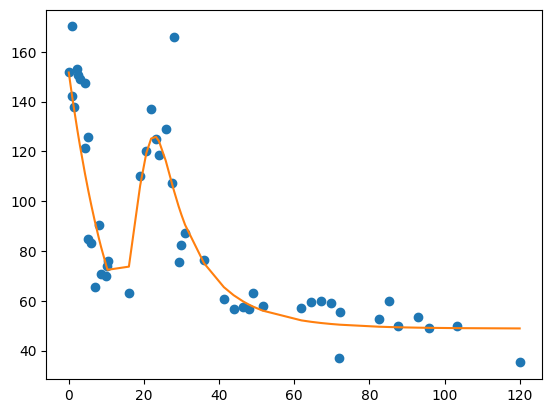

In [2]:
path = "../results/ENSDARG00000000861/numpyro_posterior.nc"
obs = xr.load_dataset(path, group="observed_data").y.mean("source")
pred = xr.load_dataset(path, group="posterior_model_fits").y.mean(dim=("draw", "chain", "source"))
rho = spearmanr(obs.values, pred.values).correlation
print(rho)

plt.plot(obs.time, obs, "o")
plt.plot(pred.time, pred)

In [3]:
idata = az.from_netcdf(path)
idata

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data
	> posterior_model_fits
	> posterior_residuals

In [8]:
import numpy as np

ll = idata.log_likelihood.to_array().values  # or select var_name
print("Any NaN?", np.any(np.isnan(ll)))
print("Any Inf?", np.any(np.isinf(ll)))
print("Min/Max:", ll.min(), ll.max())
print("Per-observation variance range:", 
      ll.reshape(-1, ll.shape[-1]).var(axis=0).min(),
      ll.reshape(-1, ll.shape[-1]).var(axis=0).max())

Any NaN? False
Any Inf? False
Min/Max: -7.554338 1.1786329
Per-observation variance range: 0.08175602 0.27209792


In [24]:
idata_b = az.from_netcdf("../results/ENSDARG00000000018_Basic/numpyro_posterior.nc")
idata_m = az.from_netcdf("../results/ENSDARG00000000018_Rep_M/numpyro_posterior.nc")
idata_z = az.from_netcdf("../results/ENSDARG00000000018_Rep_Z/numpyro_posterior.nc")
idata_v = az.from_netcdf("../results/ENSDARG00000000018_Rep_V/numpyro_posterior.nc")

dict = {"Basic": idata_b,
        "Rep_M": idata_m,
        "Rep_Z": idata_z,
        "Rep_V": idata_v}
dict1 = dict.copy()

for x in dict:
        idata = dict[x]
        ll = idata.log_likelihood["y"]  # dims: (chain, draw, time, source)
        grouped_ll = ll.sum(dim="source")   # -> dims: (chain, draw, time)
        idata_grouped = az.InferenceData(posterior=idata.posterior, log_likelihood=xr.Dataset({"y": grouped_ll}),)
        dict1[x] = idata_grouped
print(az.compare(dict1))

c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


       rank   elpd_loo     p_loo  elpd_diff        weight        se       dse  \
Rep_V     0 -13.755157  8.355798   0.000000  1.000000e+00  5.575635  0.000000   
Rep_Z     1 -14.952022  6.690565   1.196865  7.567280e-13  5.269500  0.707750   
Rep_M     2 -15.540750  6.841498   1.785593  4.121148e-13  5.309828  0.627610   
Basic     3 -50.956989  3.337950  37.201833  0.000000e+00  8.697937  7.859753   

       warning scale  
Rep_V     True   log  
Rep_Z    False   log  
Rep_M     True   log  
Basic    False   log  


c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


30.007615283875708


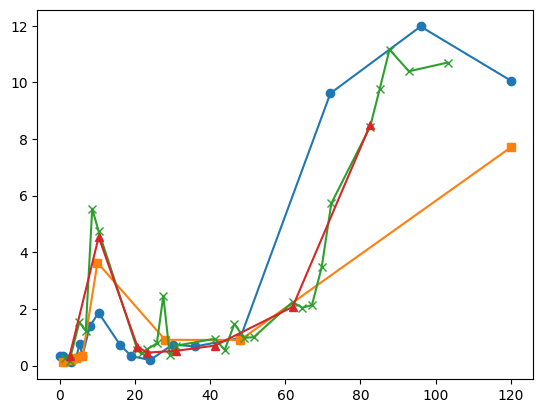

In [4]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
gene = ds.ensembl_gene_id[20]
ds1 = ds.sel(source="White").tpm.sel(ensembl_gene_id=gene).dropna(dim="time", how="all", )
ds2 = ds.sel(source="Pauli").tpm.sel(ensembl_gene_id=gene).dropna(dim="time", how="all", )
ds3 = ds.sel(source="BK").tpm.sel(ensembl_gene_id=gene).dropna(dim="time", how="all", )
ds4 = ds.sel(source="JN").tpm.sel(ensembl_gene_id=gene).dropna(dim="time", how="all", )

ds0= ds2
# common grid spanning the overlapping time range
t_start = max(ds1.time.values[0], ds0.time.values[0])
t_end = min(ds1.time.values[-1], ds0.time.values[-1])
grid = np.linspace(t_start, t_end, num=200)

v1_interp = interpolate_to_grid(ds1.time.values, ds1.values, grid)
v2_interp = interpolate_to_grid(ds0.time.values, ds0.values, grid)

distance = dtw.distance(v1_interp, v2_interp)
print(distance)

plt.plot(ds1.time, ds1, "o-")
plt.plot(ds2.time, ds2, "s-")
plt.plot(ds3.time, ds3, "x-")
plt.plot(ds4.time, ds4, "^-")
plt.show()

### 24 hpf

In [ ]:
ds24 = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 24))
ds24["tpm"] = np.log2(ds24.tpm + 1)

ds_clean24 = ds24.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean24.tpm.max(dim="time", skipna=True) >= 1).any(dim="source")
ds_filtered24 = ds_clean24.sel(ensembl_gene_id=mask)

traj24 = xr.load_dataarray("results/all_gene_trajectories_24.nc")
gof24 = pd.read_csv("results/gof_trajectories_24.csv")
gof24.groupby("source").sum("accepted") / gof24.groupby("source").count().drop(columns="ensembl_gene_id")

,nrmse,accepted
source,,
BK,0.260398,0.487624
JN,0.333862,0.511715
Pauli,0.527503,0.306701
White,0.208357,0.640836


Mean NRMSE:  source
BK       0.260398
JN       0.333862
Pauli    0.527503
White    0.208357
Name: nrmse, dtype: float64 



<Axes: title={'center': 'Accepted NRMSE by Source (24 hpf)'}, ylabel='Source'>

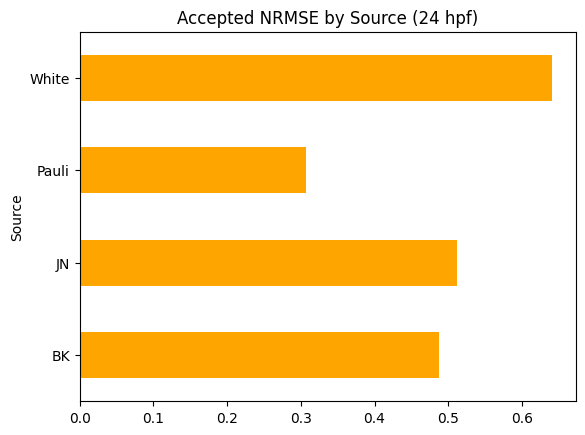

In [6]:
print("Mean NRMSE: ", gof24.groupby("source").nrmse.mean(), "\n")
gof24.groupby("source").nrmse.mean().plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (24)")
plt.close()

(gof24.groupby("source").accepted.sum() / gof24.groupby("source").count()["ensembl_gene_id"]).plot.barh(color="orange", ylabel="Source", y="% accepted", title="Accepted NRMSE by Source (24 hpf)")

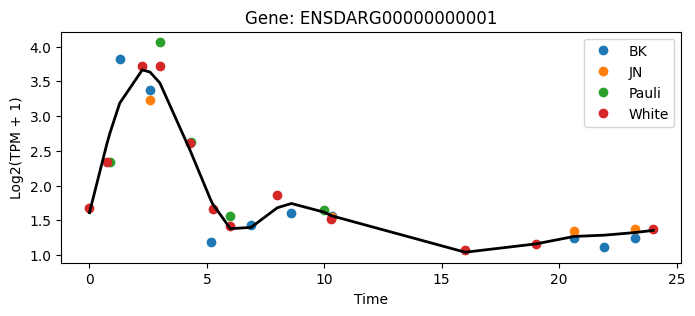

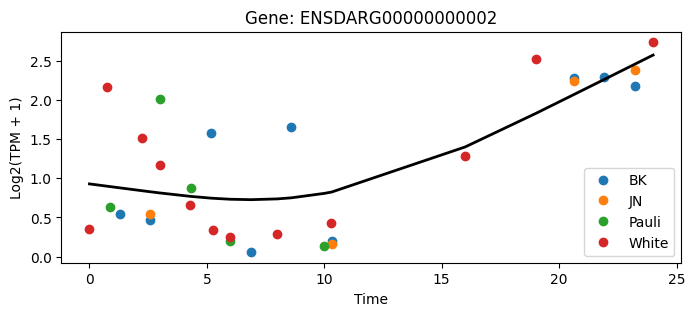

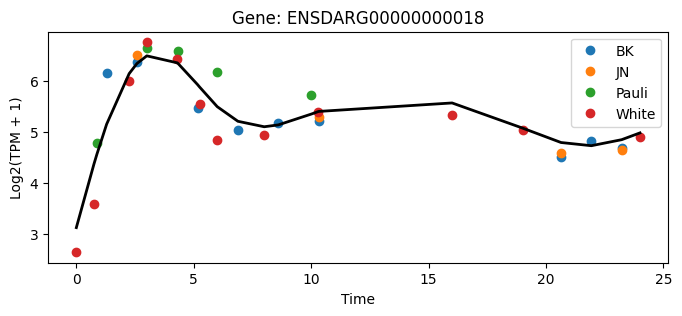

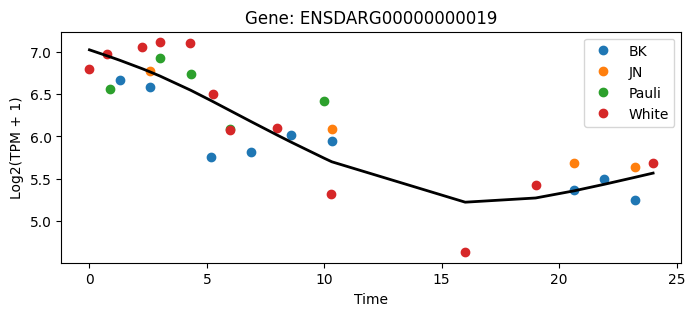

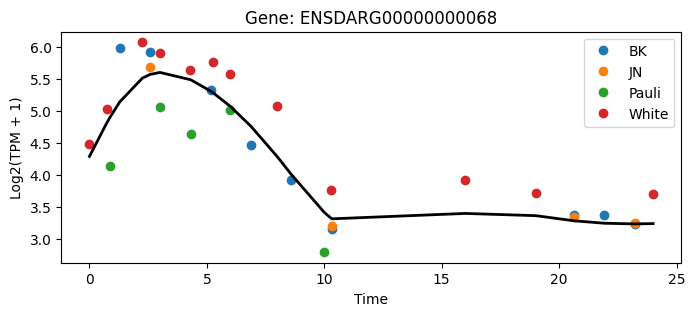

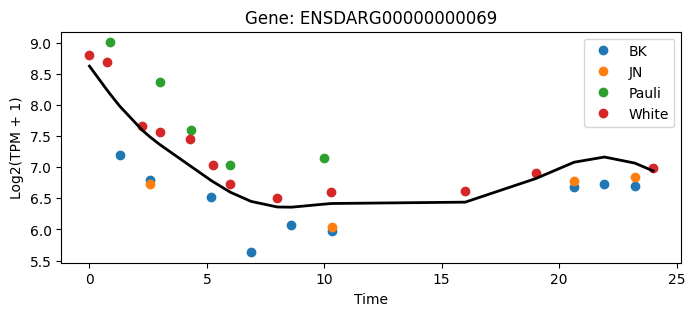

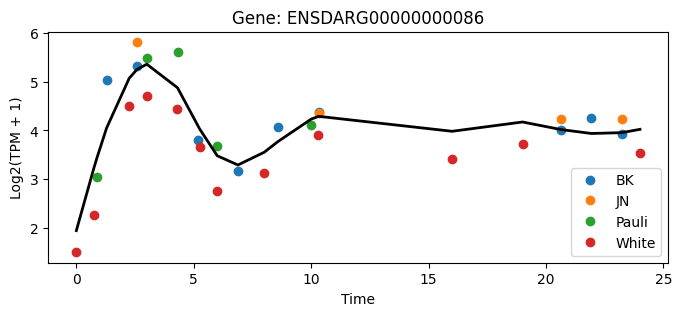

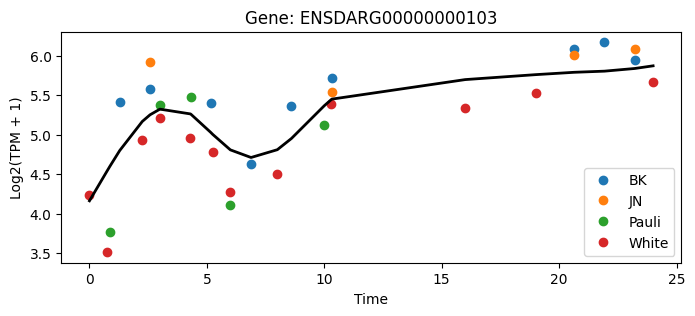

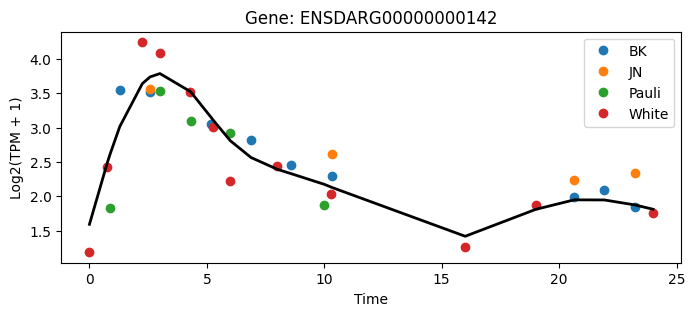

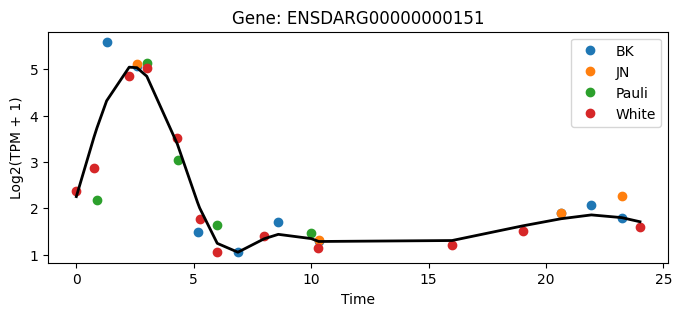

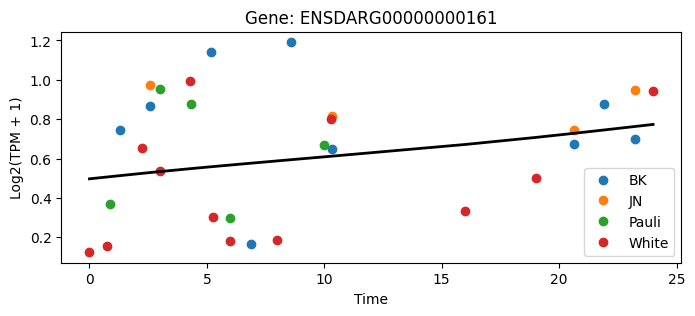

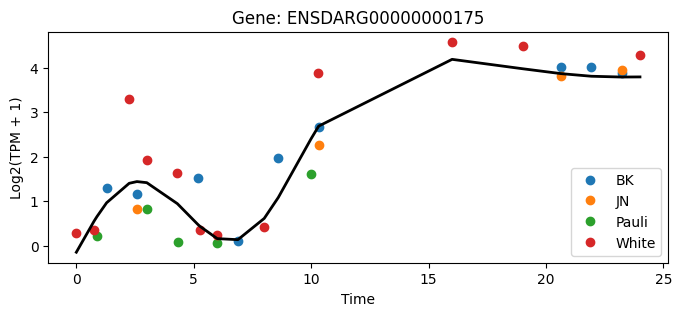

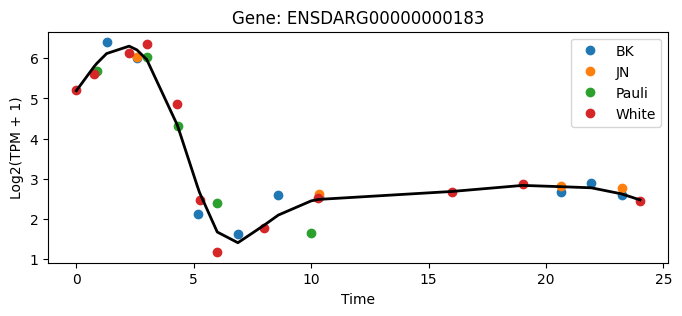

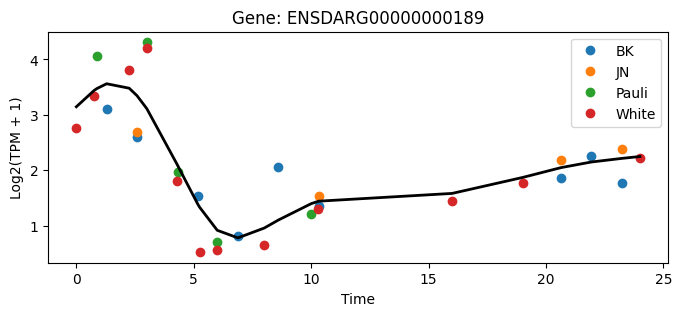

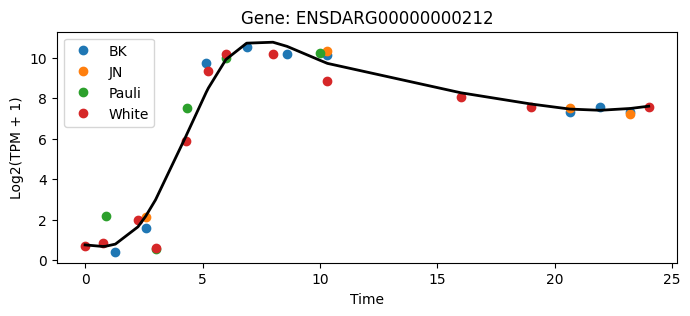

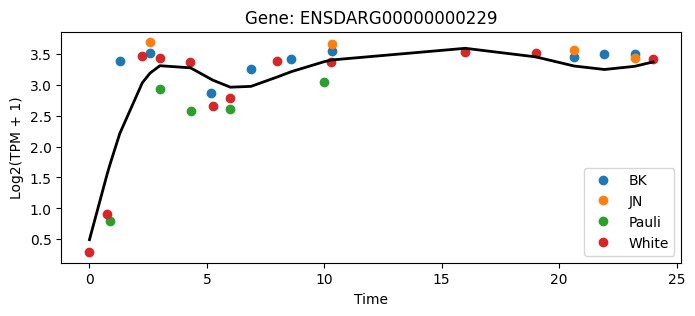

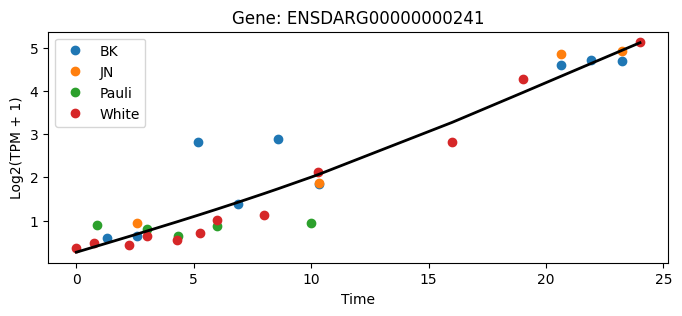

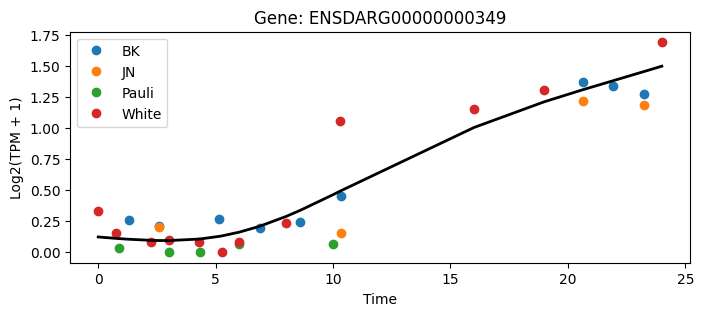

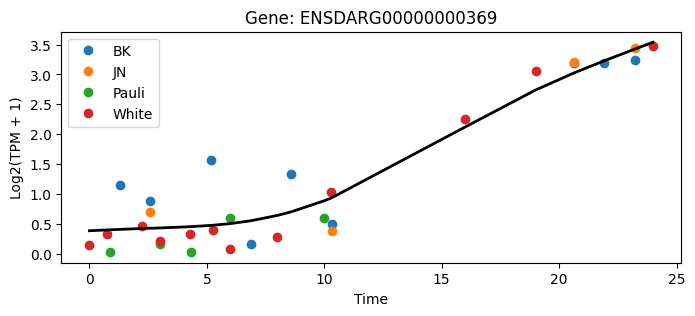

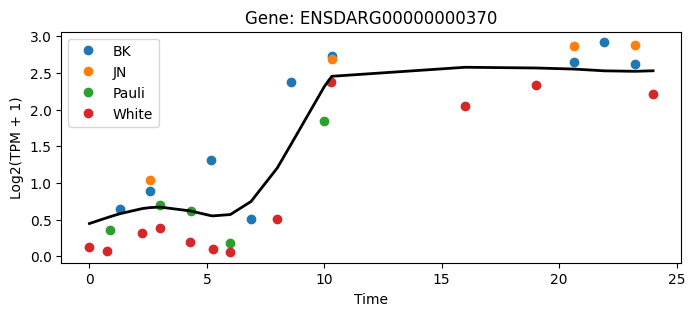

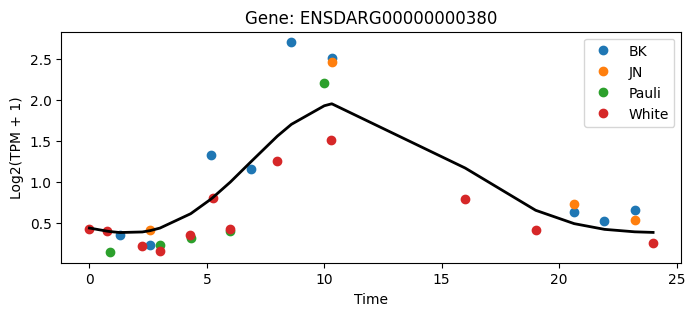

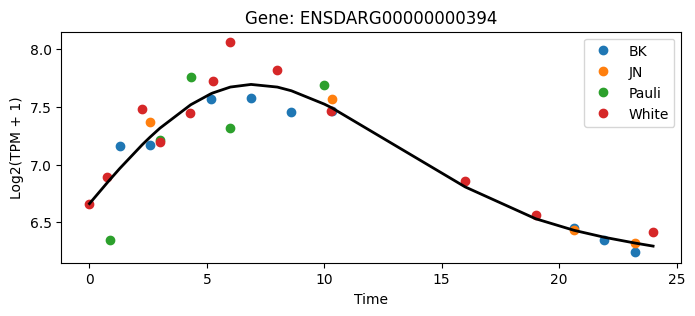

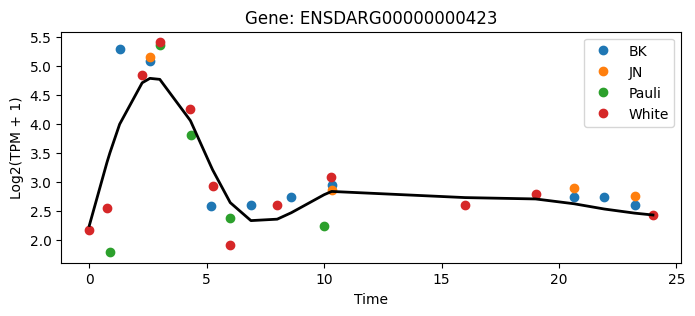

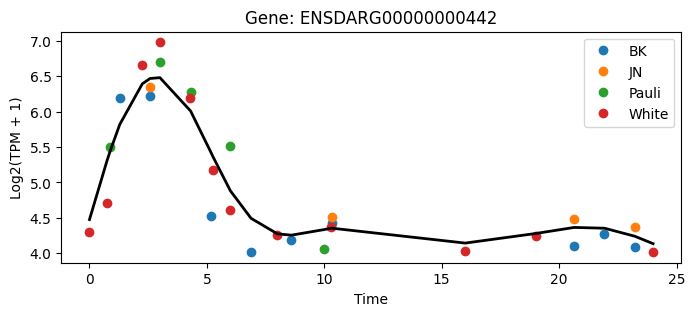

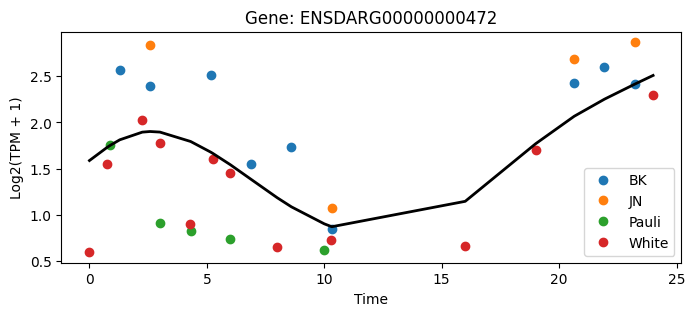

In [7]:
sc = ds24.source.values

for g in traj24.ensembl_gene_id.values[0:25]:
    y_true = ds_filtered24.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj24.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8,3))
    plt.plot(ds_filtered24.time, y_true,  marker="o", ls="", label=sc)
    plt.plot(ds_filtered24.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

## 16 hpf

In [6]:
ds16 = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 16))
ds16["tpm"] = np.log2(ds16.tpm + 1)

ds_clean16 = ds16.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean16.tpm.max(dim="time", skipna=True) >= 1).any(dim="source")
ds_filtered16 = ds_clean16.sel(ensembl_gene_id=mask)

traj16 = xr.load_dataarray("results/all_gene_trajectories_16.nc")
gof16 = pd.read_csv("results/gof_trajectories_16.csv")
gof16.groupby("source").sum("accepted") / gof16.groupby("source").count().drop(columns="ensembl_gene_id")

,nrmse,accepted
source,,
BK,0.310037,0.358332
JN,5.513748,0.388979
Pauli,0.479880,0.326319
White,0.248529,0.584642


<Axes: xlabel='nrmse', ylabel='Density'>

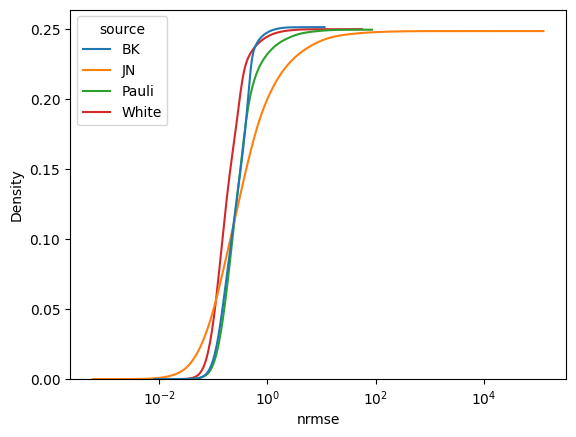

In [7]:
sns.kdeplot(gof16, x="nrmse", hue="source", log_scale=True, cumulative=True)

Mean NRMSE:  source
BK       0.310037
JN       5.513748
Pauli    0.479880
White    0.248529
Name: nrmse, dtype: float64 



<Axes: title={'center': 'Accepted NRMSE by Source (16 hpf)'}, ylabel='Source'>

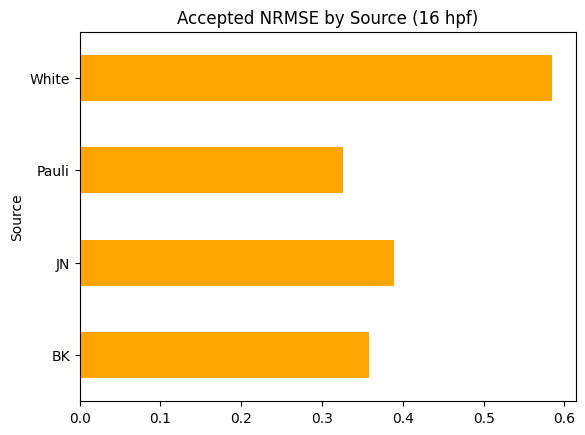

In [8]:
print("Mean NRMSE: ", gof16.groupby("source").nrmse.mean(), "\n")
gof16.groupby("source").nrmse.mean().plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (24)")
plt.close()

(gof16.groupby("source").accepted.sum() / gof16.groupby("source").count()["ensembl_gene_id"]).plot.barh(color="orange", ylabel="Source", y="% accepted", title="Accepted NRMSE by Source (16 hpf)")

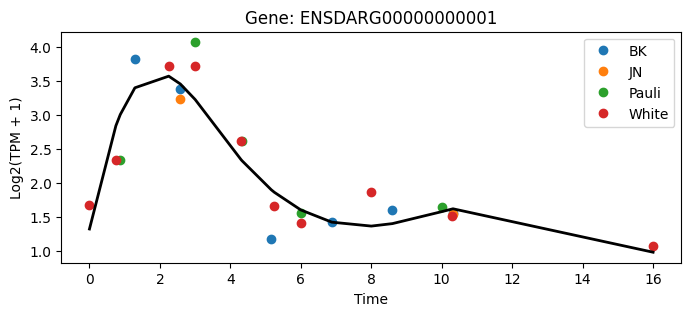

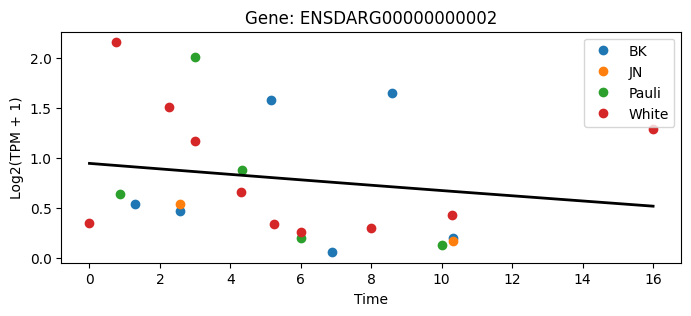

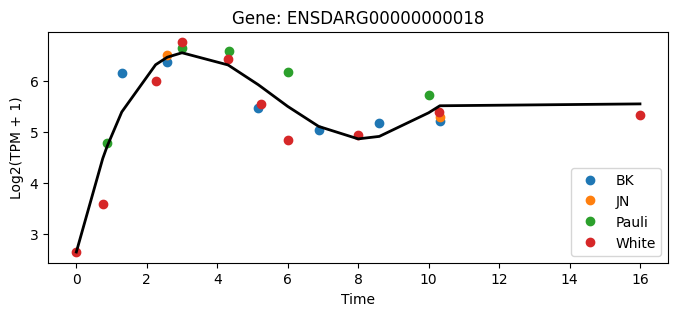

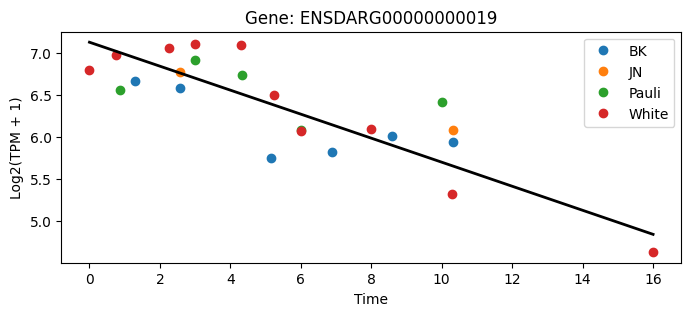

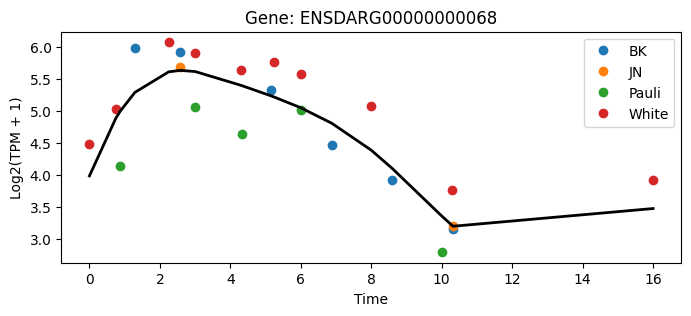

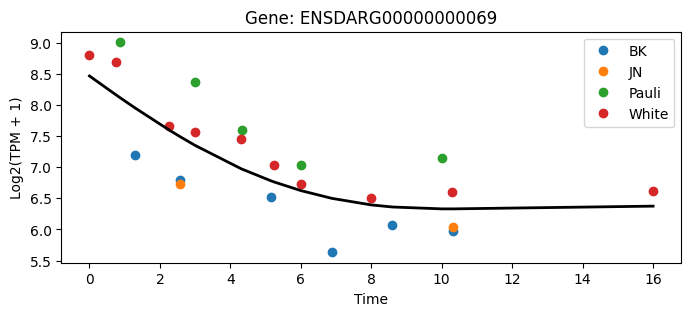

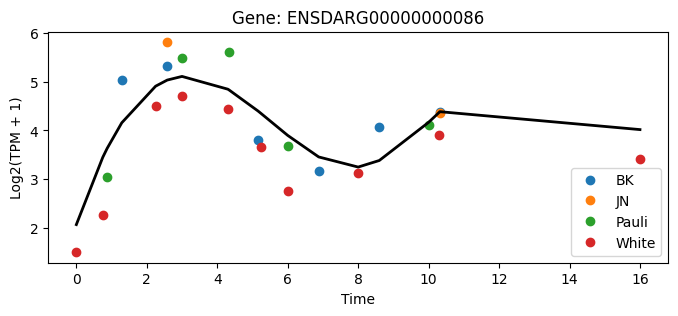

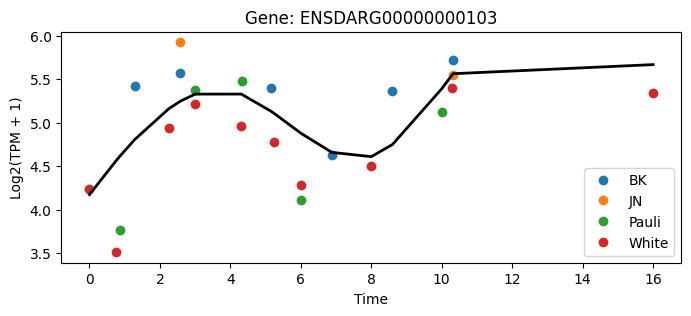

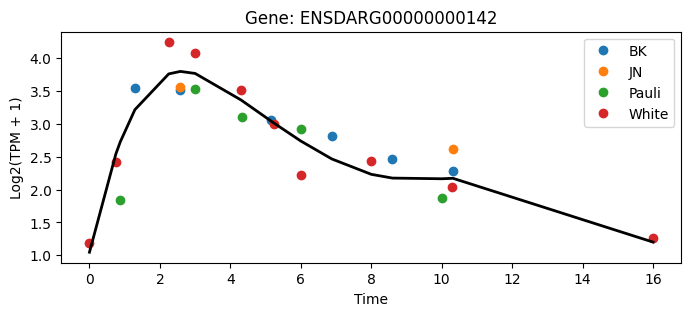

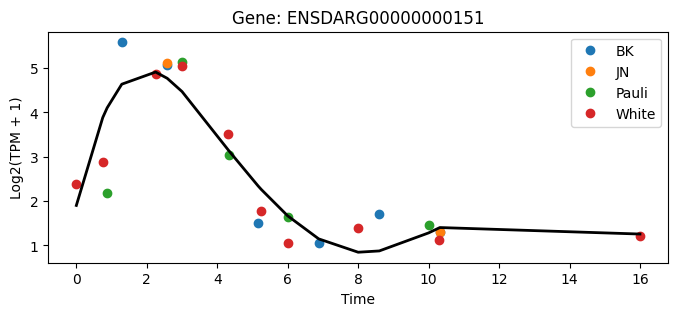

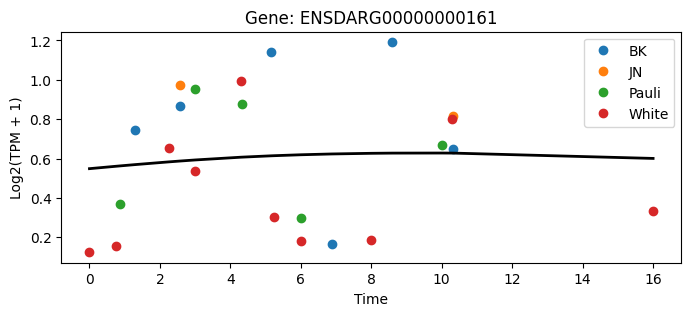

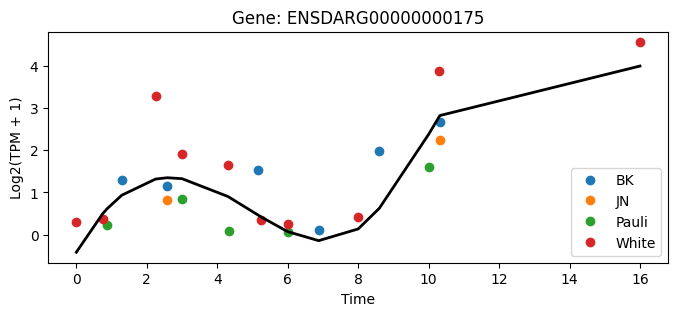

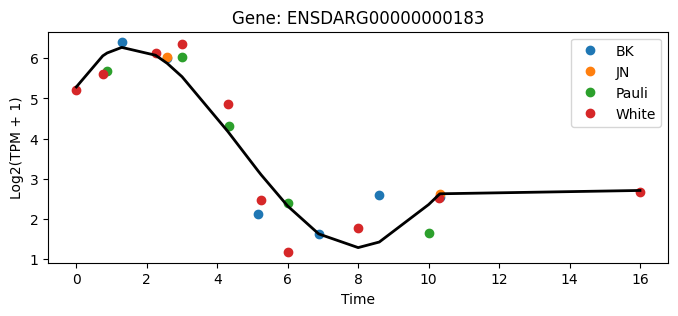

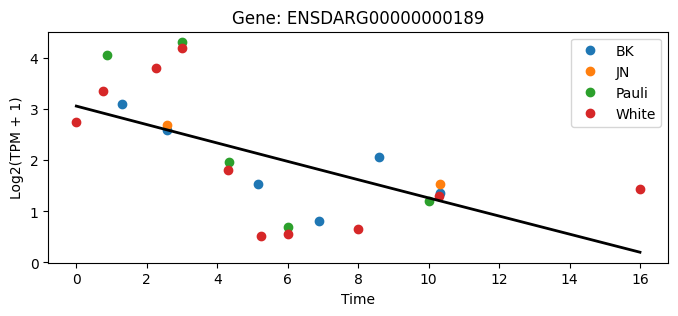

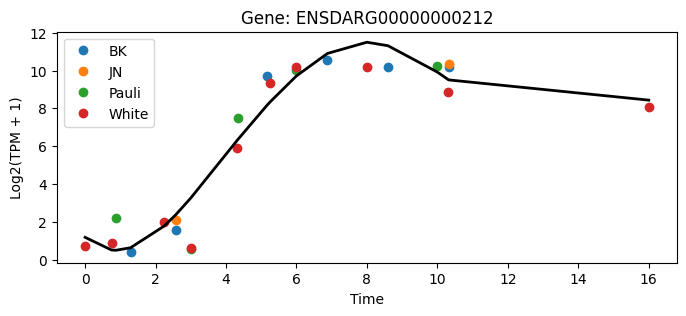

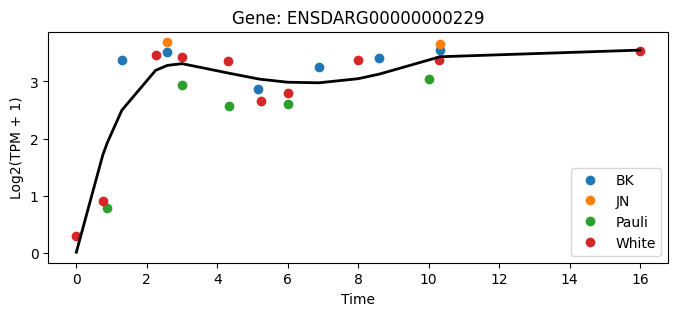

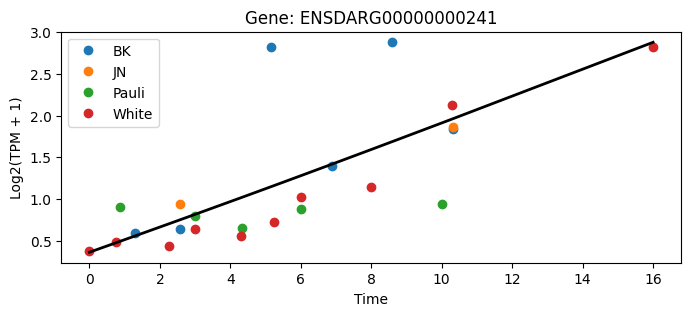

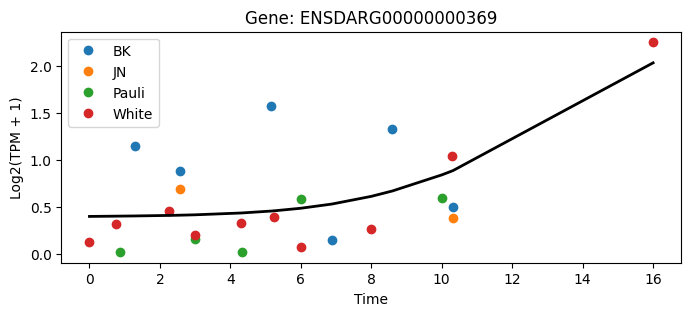

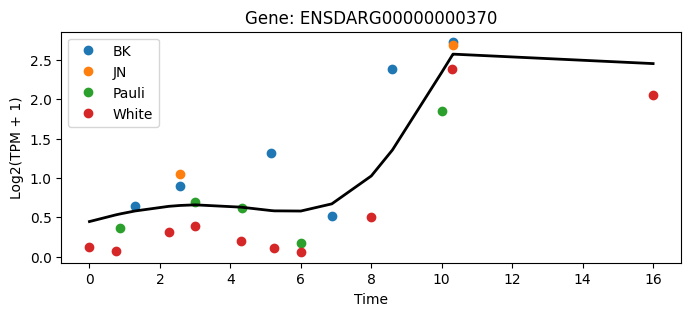

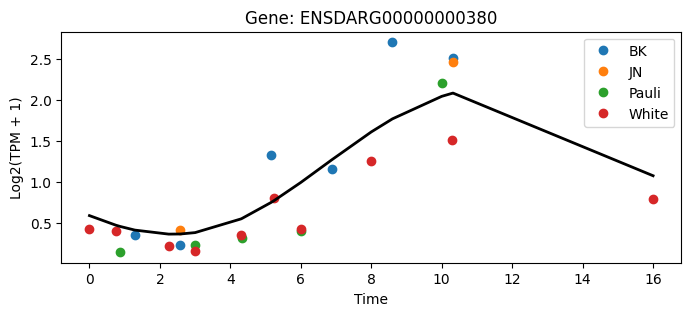

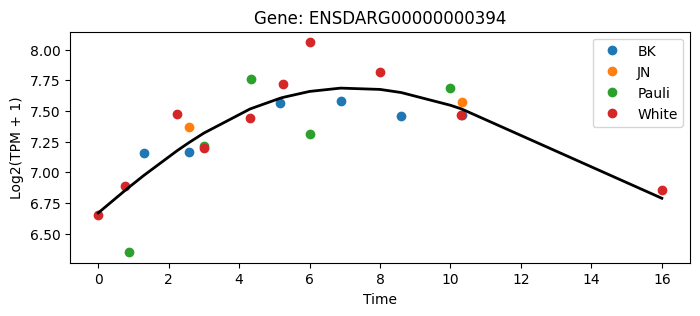

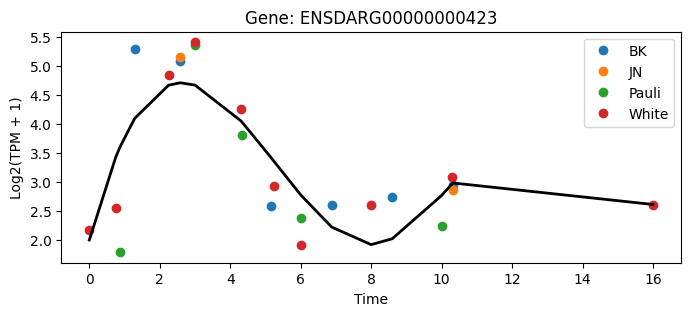

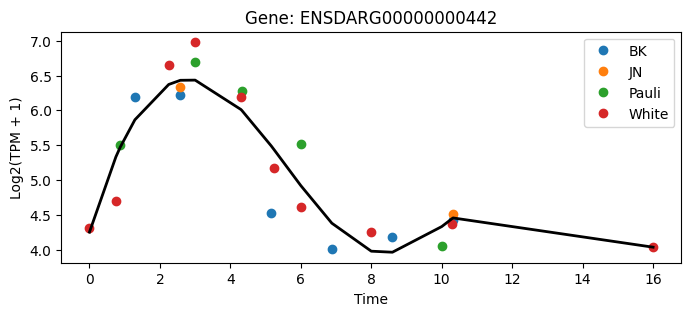

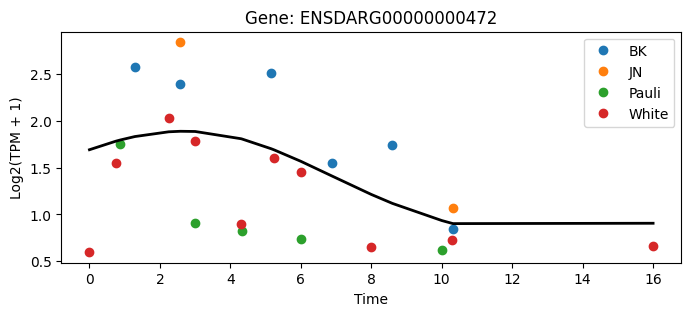

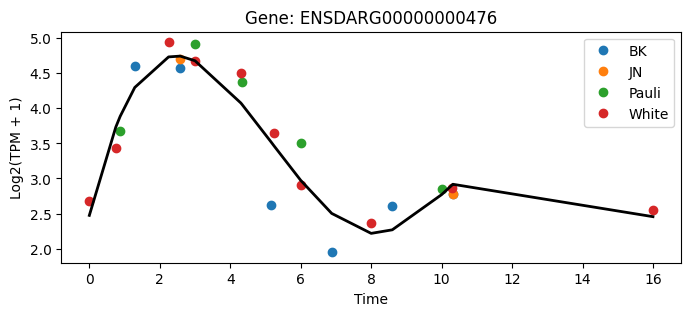

In [9]:
sc = ds16.source.values

for g in traj16.ensembl_gene_id.values[0:25]:
    y_true = ds_filtered16.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj16.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8,3))
    plt.plot(ds_filtered16.time, y_true,  marker="o", ls="", label=sc)
    plt.plot(ds_filtered16.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

Kept 23428 / 23428 genes after dynamic range filter (>= 1.0 log2 units)


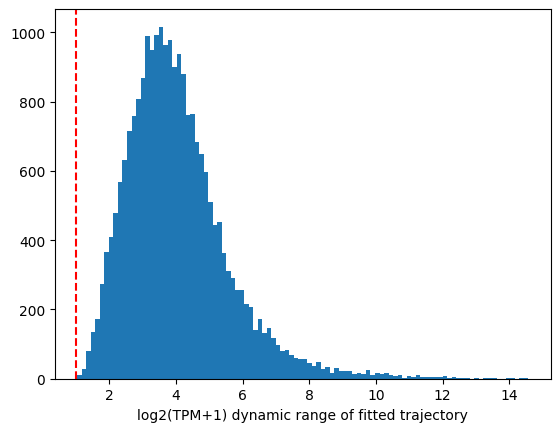

In [10]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = ((ds_clean.tpm.max(dim="time", skipna=True) >= 1) & (ds_clean.tpm.std(("time")) > 0.05)).all(dim="source")
ds_clean = ds_clean.sel(ensembl_gene_id=mask)
ds_clean["tpm"] = np.log2(ds_clean.tpm + 1)

# Compute dynamic range of fitted trajectory in log2(TPM+1) space, before min-max scaling
dyn_range = ds_clean.tpm.max(dim=("time", "source")) - ds_clean.tpm.min(dim=("time", "source"))

MIN_LOG2_RANGE = 1.0  # e.g. >= 2-fold change; tune based on inspection below
range_mask = dyn_range >= MIN_LOG2_RANGE
trajectories_filtered = ds_clean.sel(ensembl_gene_id=range_mask)

print(f"Kept {range_mask.sum().item()} / {ds_clean.sizes['ensembl_gene_id']} genes "
      f"after dynamic range filter (>= {MIN_LOG2_RANGE} log2 units)")

import matplotlib.pyplot as plt
dyn_range.plot.hist(bins=100)
plt.axvline(MIN_LOG2_RANGE, color="red", linestyle="--")
plt.xlabel("log2(TPM+1) dynamic range of fitted trajectory")
plt.show()

### heatmap

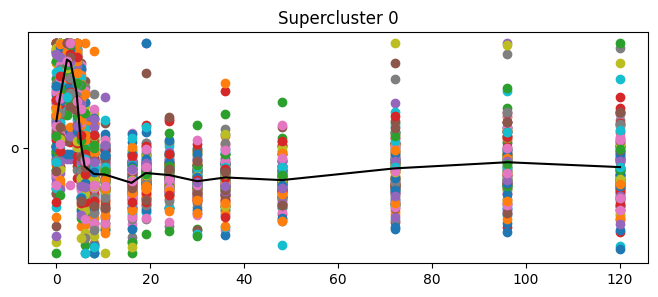

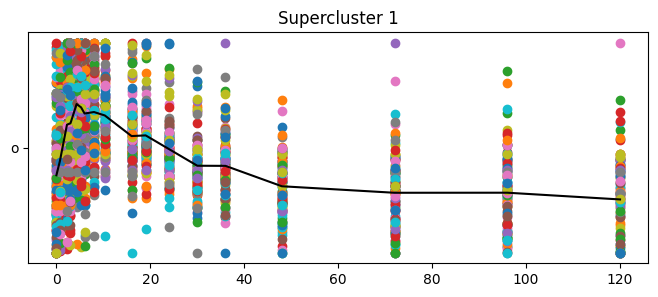

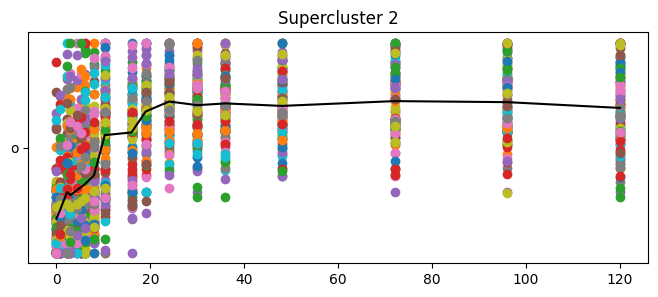

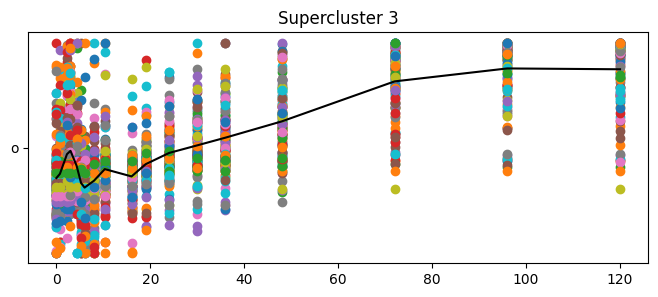

In [80]:
ann = xr.load_dataset("results/all_gene_cluster_annotation_minmax.nc").sel(source="White", drop=True)
ann = ann.dropna(dim="time", how="all", subset=["tpm"])
ann = ann.sel(ensembl_gene_id=ann.ensembl_gene_id.values[0:500])

ann["tpm"] = np.log2(ann.tpm+1)

for s in np.unique(ann.supercluster.values):
    plt.figure(figsize=(8, 3))
    X = ann.sel(ensembl_gene_id=ann.supercluster == s).tpm
    X_z = (X - X.mean("time")) / abs(X- X.mean("time")).max("time")

    if "source" in X_z.dims:
        tpm = tpm.mean(dim="source", skipna=True)   # or .sel(source="...") for one source

    plt.plot(X.time, X_z, "o")
    plt.plot(X.time, X_z.mean(dim="ensembl_gene_id"), "k", "o")
    plt.title(f"Supercluster {s}")
    plt.show()

### Sankey diagramm

In [12]:
from pySankey.sankey import sankey
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def cluster_agreement(ds1, ds2, algo1, algo2):

   df1 = pd.DataFrame({"ensembl_gene_id": ds1.ensembl_gene_id.values, "cluster":ds1.values})
   df2 = pd.DataFrame({"ensembl_gene_id": ds2.ensembl_gene_id.values, "cluster2":ds2.values})

   dup1 = df1["ensembl_gene_id"].duplicated().sum()
   dup2 = df2["ensembl_gene_id"].duplicated().sum()
   if dup1 or dup2:
      print(f"Warning: {dup1} duplicate ids in ds1, {dup2} duplicate ids in ds2")

   df = df1.merge(df2, on="ensembl_gene_id", how="inner", validate="one_to_one")

   df["agreement"] = (df["cluster"] == df["cluster2"])
   df = df.dropna(subset=["cluster", "cluster2"])
   df = df.sort_values(["cluster", "cluster2"], ascending=False)

   sankey(left=df["cluster"], right=df["cluster2"], 
         aspect=20, fontsize=12,
         figure_name=f"figs/cluster_agreement_{algo1}_{algo2}")

   # Get current figure
   fig = plt.gcf()
   fig.set_size_inches(6, 6)
   fig.set_facecolor("w")
   plt.title(f"Cluster changes \n({algo1} → {algo2})")
   fig.savefig(f"figs/cluster_agreement_{algo1}_{algo2}.png", bbox_inches="tight", dpi=300)

   agree = df["agreement"].sum() / len(df) * 100
   print(f"Cluster agreement: {agree:.2f} %")

   return df

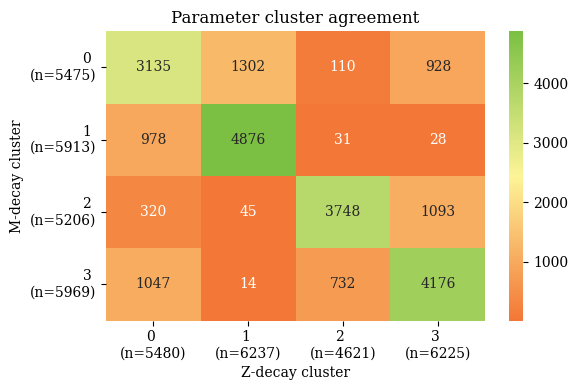

In [83]:
ds0 = xr.load_dataset("results/all_gene_cluster_annotation_minmax.nc").supercluster
ds1 = xr.load_dataset("results/Rep_M_model_params_labels.nc").cluster_label
ds2 = xr.open_dataset("results/Rep_Z_model_params_labels.nc").cluster_label

cmap = sns.color_palette("blend:#f37736,#fdf498,#7bc043", as_cmap=True)

df0 = pd.DataFrame({"ensembl_gene_id": ds0.ensembl_gene_id.values, "Expression cluster":ds0.values})
df1 = pd.DataFrame({"ensembl_gene_id": ds1.ensembl_gene_id.values, "M-decay cluster":ds1.values})
df2 = pd.DataFrame({"ensembl_gene_id": ds2.ensembl_gene_id.values, "Z-decay cluster":ds2.values})
df = df1.merge(df2, on="ensembl_gene_id", how="inner", validate="one_to_one")

matr = df.groupby(["M-decay cluster", "Z-decay cluster"]).count().reset_index()
df_plot = matr.pivot(index="M-decay cluster", columns=["Z-decay cluster"], values="ensembl_gene_id")
import seaborn as sns
row_totals = df.groupby("M-decay cluster")["ensembl_gene_id"].count()
col_totals = df.groupby("Z-decay cluster")["ensembl_gene_id"].count()

ylabels = [f"{idx} \n(n={row_totals.loc[idx]})" for idx in df_plot.index]
xlabels = [f"{col} \n(n={col_totals.loc[col]})" for col in df_plot.columns]

fig, ax = plt.subplots(figsize=(6, 4),)
sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f")
ax.set_yticklabels(ylabels, rotation=0)
ax.set_xticklabels(xlabels, rotation=0)
plt.title(f"Parameter cluster agreement")
plt.tight_layout()
plt.savefig("figs/cluster_agreemenr_heatmap_Rep_M_Z.png", dpi=300)

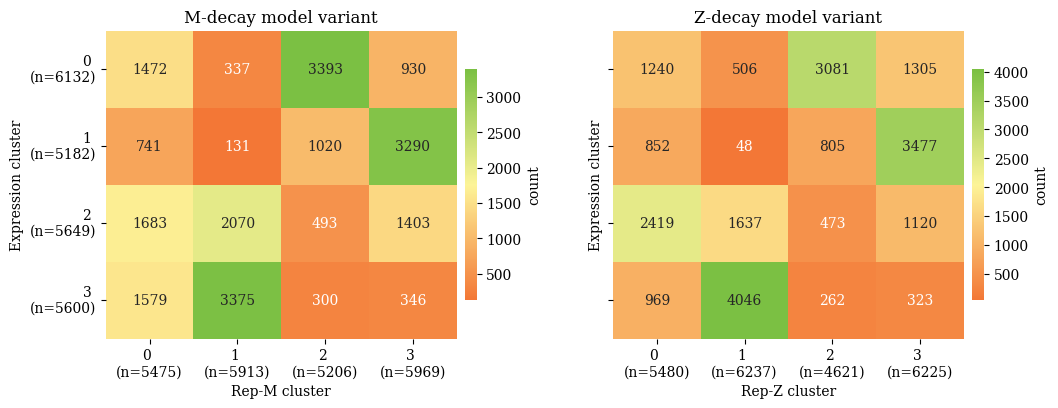

In [79]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12, 4), sharey=True)

# M-decay 
df = df0.merge(df1, on="ensembl_gene_id", how="inner", validate="one_to_one")
matr = df.groupby(["Expression cluster", "Rep-M cluster"]).count().reset_index()
df_plot = matr.pivot(index="Expression cluster", columns=["Rep-M cluster"], values="ensembl_gene_id")
import seaborn as sns

row_totals = df.groupby("Expression cluster")["ensembl_gene_id"].count()
col_totals = df.groupby("Rep-M cluster")["ensembl_gene_id"].count()
ylabels = [f"{idx} \n(n={row_totals.loc[idx]})" for idx in df_plot.index]
xlabels = [f"{col} \n(n={col_totals.loc[col]})" for col in df_plot.columns]

sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax1, 
            cbar_kws={'label': 'count', 'shrink': 0.75, 'pad': 0.02 })
ax1.set_yticklabels(ylabels, rotation=0)
ax1.set_xticklabels(xlabels, rotation=0)
ax1.set_title(f"M-decay model variant")

## Z-decay
df = df0.merge(df2, on="ensembl_gene_id", how="inner", validate="one_to_one")
matr = df.groupby(["Expression cluster", "Rep-Z cluster"]).count().reset_index()
df_plot = matr.pivot(index="Expression cluster", columns=["Rep-Z cluster"], values="ensembl_gene_id")
import seaborn as sns

row_totals = df.groupby("Expression cluster")["ensembl_gene_id"].count()
col_totals = df.groupby("Rep-Z cluster")["ensembl_gene_id"].count()
ylabels = [f"{idx} \n(n={row_totals.loc[idx]})" for idx in df_plot.index]
xlabels = [f"{col} \n(n={col_totals.loc[col]})" for col in df_plot.columns]

sns.heatmap(df_plot,annot=True, cmap=cmap, fmt=".0f", ax=ax2,
            cbar_kws={'label': 'count', 'shrink': 0.75, 'pad': 0.02 })
ax2.set_yticklabels(ylabels, rotation=0)
ax2.set_xticklabels(xlabels, rotation=0)
ax2.set_title(f"Z-decay model variant")

plt.savefig("figs/cluster_agreemenr_heatmap_Rep_Z_M_Expr.png", dpi=300)

Cluster agreement: 11.04 %
Cluster agreement: 16.41 %
Cluster agreement: 30.08 %


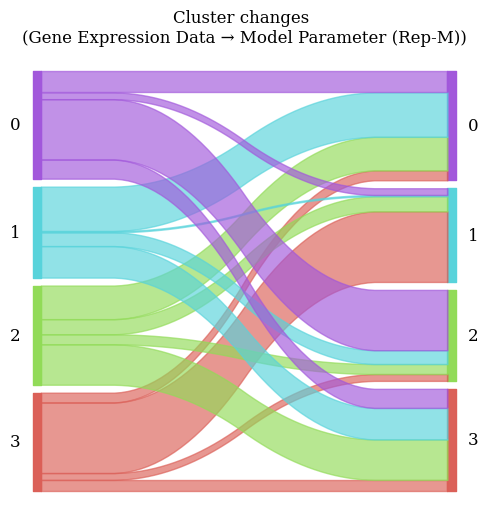

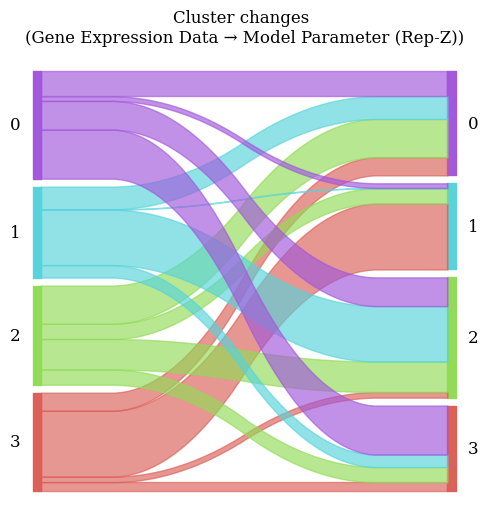

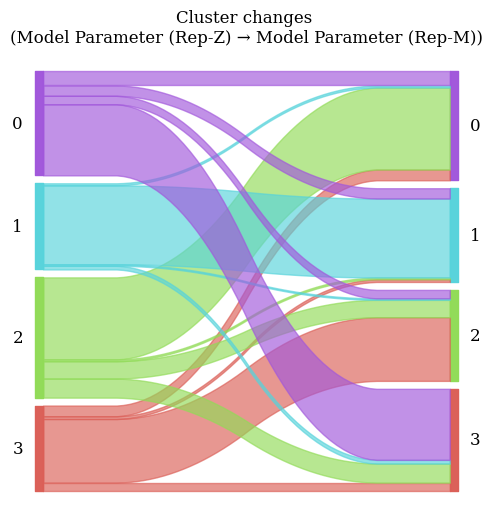

In [21]:
import xarray as xr

algo1 = "Gene Expression Data"
ds1 = ds1 = xr.load_dataset("results/all_gene_cluster_annotation_minmax.nc").supercluster

algo2 = "Model Parameter (Rep-M)"
ds2 = xr.load_dataset("results/kinetic_params_Rep_M_labels.nc").cluster_label

algo3 = "Model Parameter (Rep-Z)"
ds3 = xr.open_dataset("results/kinetic_params_Rep_Z_labels.nc").cluster_label

# algo2 = "ts_k-means"
# ds2 = xr.load_dataset("results/ts_k-means_euclidean_clustered_ds_White et al..nc")

#algo2 = "k-medoids"
#ds2 = xr.load_dataset("results/k_medoids_clustered_ds_White et al..nc")
df = cluster_agreement(ds1, ds2, algo1, algo2)
df = cluster_agreement(ds1, ds3, algo1, algo3)
df = cluster_agreement(ds3, ds2, algo3, algo2)

In [4]:
# Clustering
import xarray as xr
import numpy as np
import pandas as pd
import fuzzy_clustering1 as fc

traj120 = xr.load_dataarray(f"results/all_normalized_trajectories_24_minmax.nc")
membership120, labels120, centers120 = fc.cluster_dataset(traj120, f"results/early_superclusters", dataset_name="supercluster", k_range=range(4, 8))

# --- reindex superclusters by increasing peak time ---
peak_times = np.argmax(centers120.values, axis=1)      # peak time index per (old) cluster
new_order = np.argsort(peak_times)              # old cluster ids, sorted by peak time
rank = np.argsort(new_order)                    # rank[old_id] = new_id

# reorder centers
centers120 = centers120.isel(cluster=new_order).assign_coords(cluster=np.arange(len(new_order)))
centers120.to_netcdf(f"results/early_superclusters_centers.nc")

labels120 = labels120.copy(data=rank[labels120.values])  # remap gene labels to new ids
labels120.to_netcdf(f"results/early_superclusters_labels.nc")
fc.plot_clusters(centers120, "EarlySuperclusters")

Selecting best K...
K=4 | stability=0.9823 +/- 0.0081, null=0.9770 | FPC=0.6521 | XB=0.3006
K=5 | stability=0.9814 +/- 0.0066, null=0.9813 | FPC=0.6008 | XB=0.3446
K=6 | stability=0.9579 +/- 0.0182, null=0.9797 | FPC=0.5514 | XB=0.8155
K=7 | stability=0.9446 +/- 0.0231, null=0.9814 | FPC=0.5227 | XB=0.7680
Number of Clusters: 4
results/early_superclusters: K=4, FPC=0.652


In [19]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])

# Remove low expressed genes -> too noisy, no effective pattern
mask = (ds_clean.tpm.max(dim="time", skipna=True) >= 1).all(dim="source") 
ds_clean = ds_clean.sel(ensembl_gene_id=mask).sel(time=slice(0, 12))

# Reduce variance by log scaling
ds_clean["tpm"] = np.log2(ds_clean.tpm + 1) 

# z-score
mean = ds_clean.tpm.mean(dim=("time", "source"))
std = ds_clean.tpm.std(dim=("time", "source"))
ds_clean["tpm"] = (ds_clean.tpm - mean) / std

ds1= ds_clean.mean(dim="source")  # average over sources, select time range
ds1

<xarray.Dataset>
Dimensions:          (ensembl_gene_id: 23428, time: 18)
Coordinates:
  * ensembl_gene_id  (ensembl_gene_id) object 'ENSDARG00000000001' ... 'ENSDA...
  * time             (time) float64 0.0 0.75 0.875 1.29 ... 8.6 10.0 10.3 10.32
Data variables:
    tpm              (time, ensembl_gene_id) float64 -0.6682 -0.6104 ... 1.108

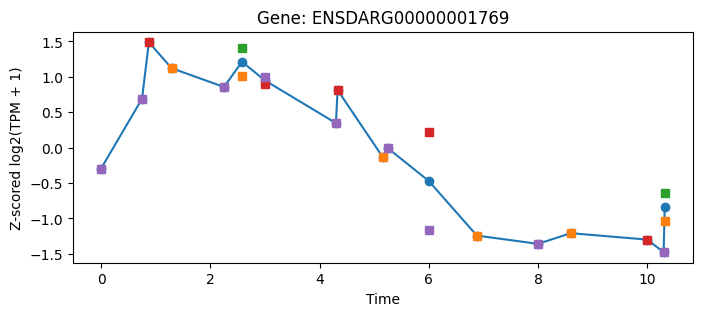

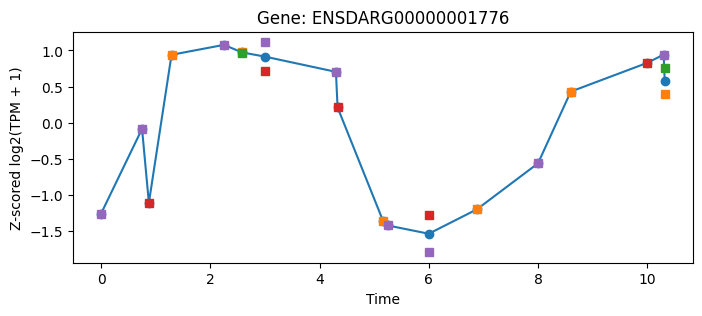

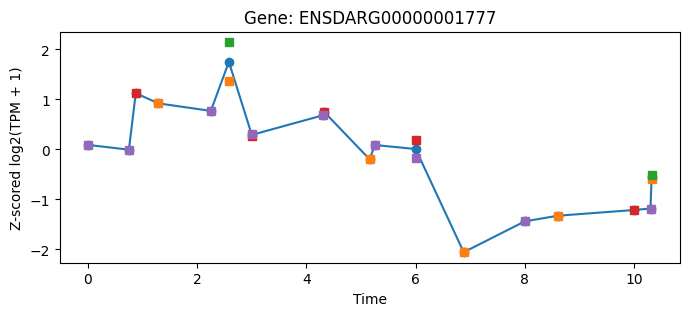

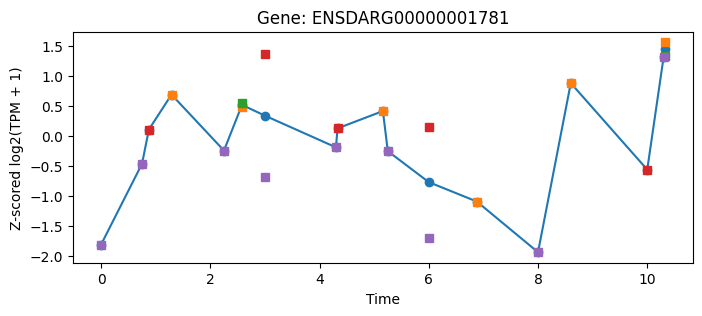

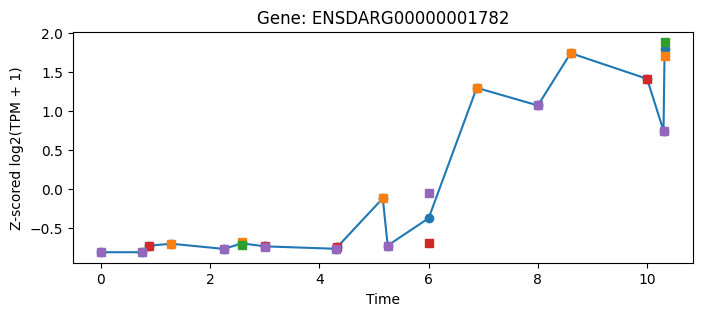

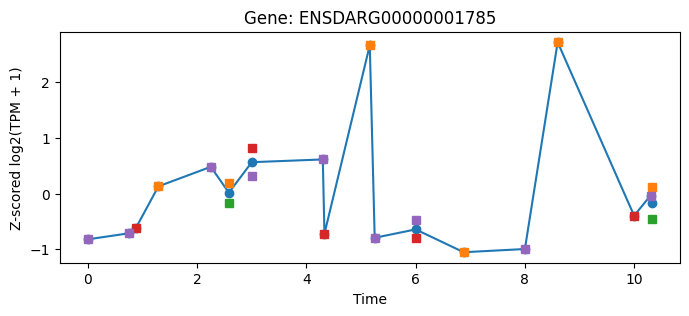

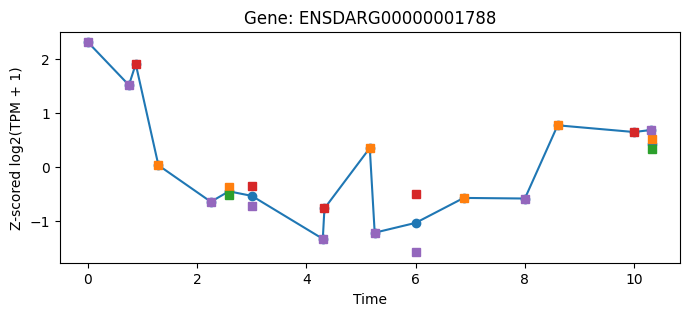

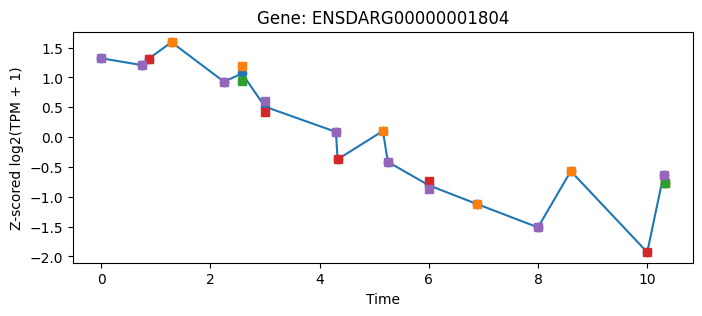

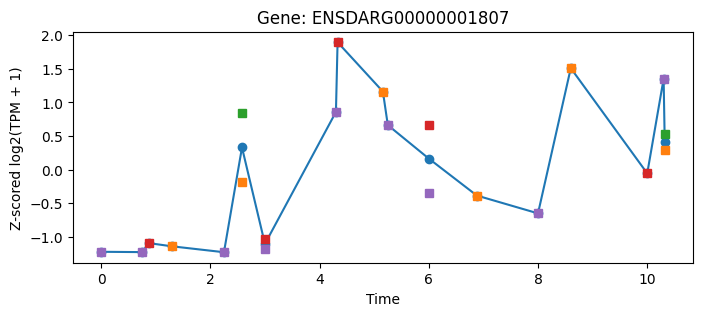

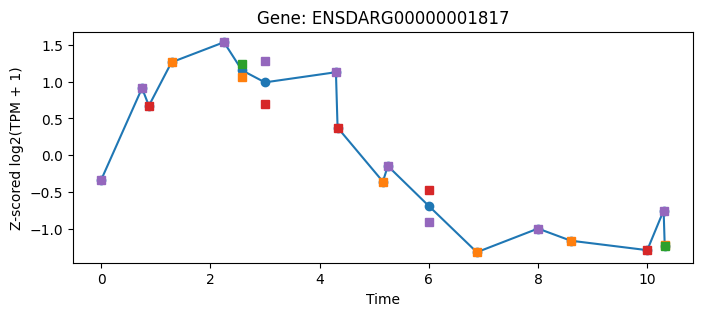

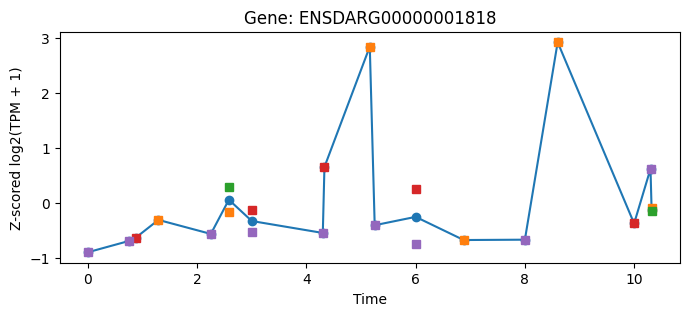

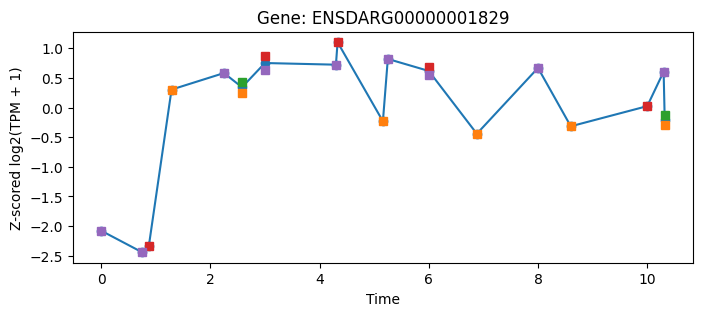

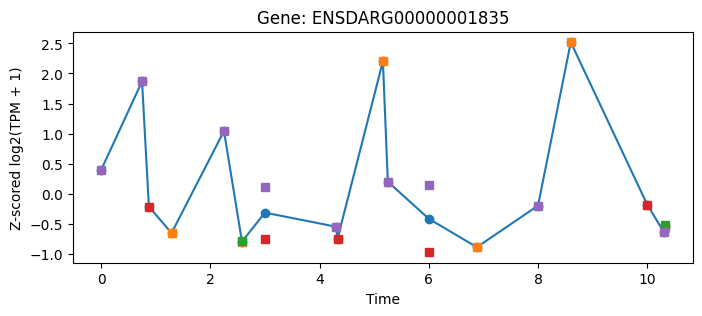

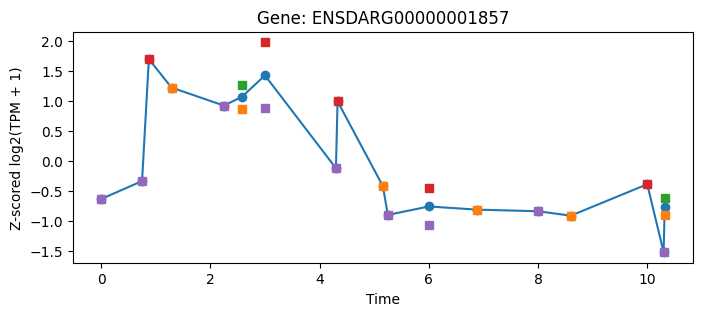

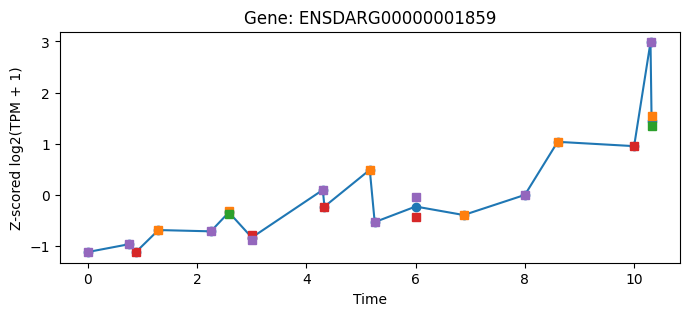

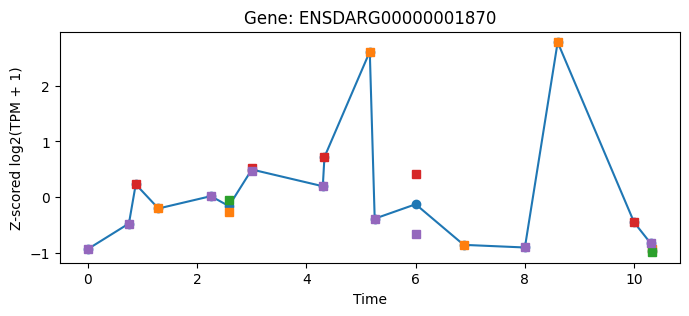

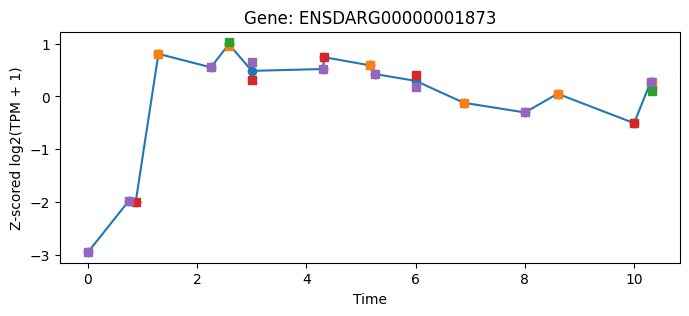

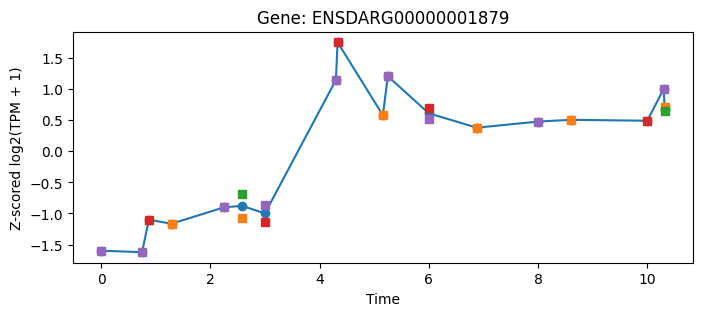

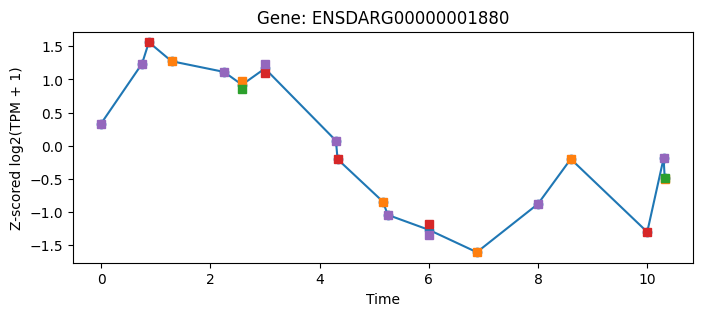

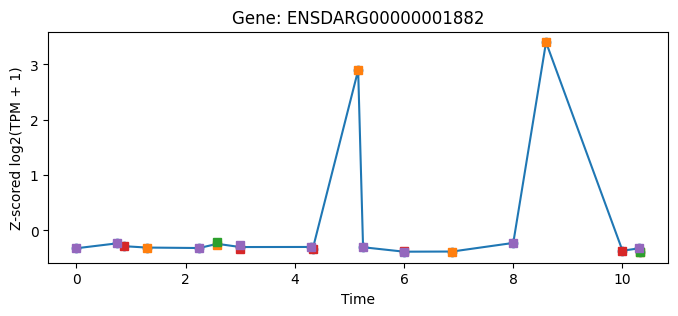

In [24]:
for g in ds1.ensembl_gene_id.values[100:120]:
    plt.figure(figsize=(8,3))
    plt.plot(ds1.time, ds1.tpm.sel(ensembl_gene_id=g), "o-")
    plt.plot(ds_clean.time, ds_clean.tpm.sel(ensembl_gene_id=g), "s")
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Z-scored log2(TPM + 1)")
    plt.show()